In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [2]:
blocks = gpd.read_parquet('../data/traning_data/prepared_blocks_service.parquet')
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,log_price,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,area_accessibility
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,6.849476,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000,low-rise non-residential,113.847998
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,7.577334,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207,individual residential,145.884534
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,7.318688,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326,individual residential,148.543184
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,7.695643,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142,low-rise model,132.691062
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,9.060062,1.000310,0.250078,0.000000,4.000000,0.749690,0.000000,4.000000,mid-rise non-residential,99.160727


In [3]:
# Собираем все имена колонок, которые начинаются на 'capacity'
cols_to_drop = [col for col in blocks.columns if col.startswith('capacity')]
blocks = blocks.drop(columns=cols_to_drop)
cols_to_drop = [col for col in blocks.columns if col.startswith('count')]
# blocks = blocks.drop(columns='cluster')
# Удаляем их сразу все
blocks = blocks.drop(columns=cols_to_drop)

blocks.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'total_cost_value', 'site_area', 'price_per_sqm',
       'log_total_price', 'log_price', 'fsi', 'gsi', 'mxi', 'l', 'osr',
       'share_living', 'share_non_living', 'morphotype', 'area_accessibility'],
      dtype='object')

In [4]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks.select_dtypes(include=['number'])
num = num[num['log_price'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
residential,8703,0.00,1.00,0.51,0.68,0.43
business,8703,0.00,1.00,0.03,0.00,0.15
recreation,8703,0.00,1.00,0.18,0.00,0.33
industrial,8703,0.00,1.00,0.05,0.00,0.19
transport,8703,0.00,1.00,0.18,0.07,0.28
special,8703,0.00,1.00,0.01,0.00,0.10
agriculture,8703,0.00,1.00,0.01,0.00,0.11
share,8692,0.00,1.00,0.85,0.91,0.16
footprint_area,8703,0.00,"818,787.73","11,961.95","3,202.12","25,274.92"


count            8,758.00
mean       499,665,093.82
std      1,024,684,189.32
min                  0.00
25%         53,828,593.17
50%        157,728,287.35
75%        487,929,639.32
max     23,532,814,433.13
Name: total_cost_value, dtype: float64


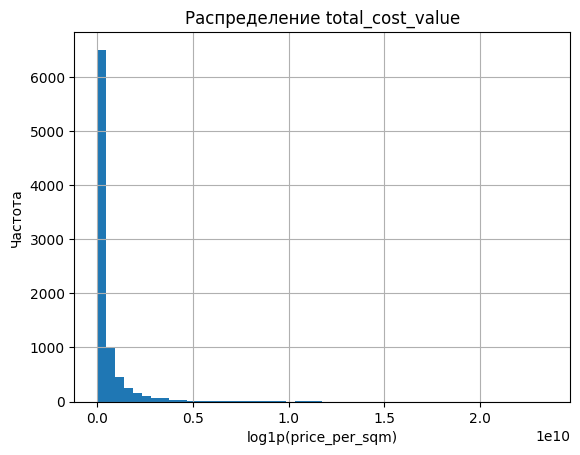

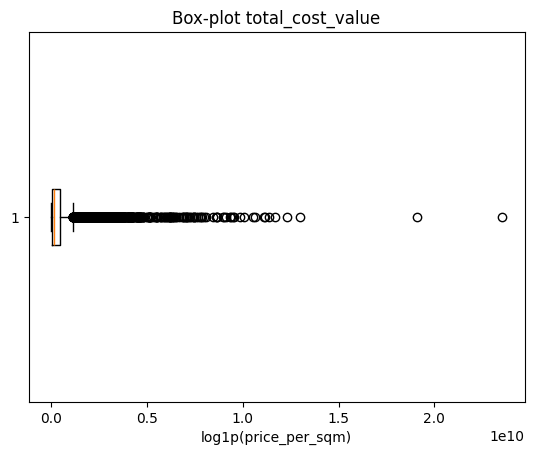

In [5]:
# Быстрая статистика
print(blocks['total_cost_value'].describe())

# Гистограмма
plt.figure()
blocks['total_cost_value'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение total_cost_value')
plt.show()

# Box-plot
plt.figure()
plt.boxplot(blocks['total_cost_value'].dropna(), vert=False)
plt.xlabel('log1p(price_per_sqm)')
plt.title('Box-plot total_cost_value')
plt.show()


count           8,582.00
mean      433,348,575.44
std       694,150,493.34
min            49,579.74
25%        55,335,637.24
50%       157,728,287.35
75%       475,911,368.17
max     4,704,239,645.28
Name: total_cost_value, dtype: float64


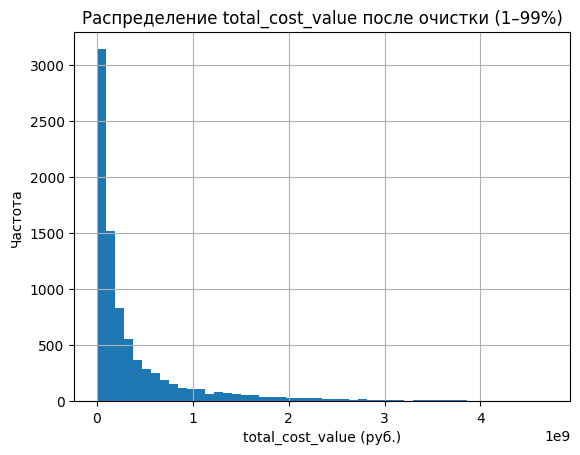

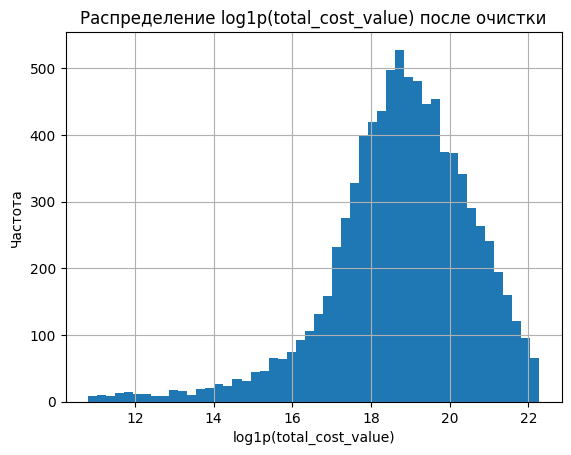

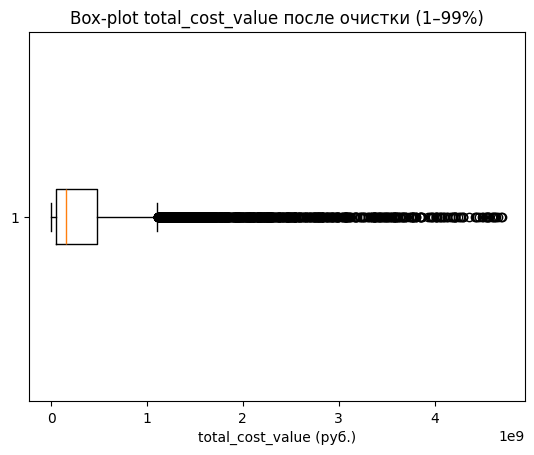

In [6]:
import numpy as np
import matplotlib.pyplot as plt

blocks = blocks.copy()

# 1) Удаляем некорректные значения площади (если участвует в признаках)
#    Если площадь не нужна — можно убрать этот фильтр, но обычно site_area должна быть > 0.
blocks = blocks[blocks["site_area"] > 0]

# 2) Удаляем некорректную целевую: нули/отрицательные
blocks = blocks[blocks["total_cost_value"] > 0]

# 3) Убираем inf и NaN (НЕ заменяем на 0)
blocks = blocks.replace([np.inf, -np.inf], np.nan)
blocks = blocks.dropna(subset=["total_cost_value"])

# 4) Обрезаем хвосты по total_cost_value (1–99 перцентили)
p1 = blocks["total_cost_value"].quantile(0.01)
p99 = blocks["total_cost_value"].quantile(0.99)

blocks_clean = blocks[
    (blocks["total_cost_value"] >= p1) &
    (blocks["total_cost_value"] <= p99)
].copy()

print(blocks_clean["total_cost_value"].describe())

# 5) Лог-цель для обучения (рекомендуется при heavy-tail)
blocks_clean["log_total_cost_value"] = np.log1p(blocks_clean["total_cost_value"])

# 6) Гистограмма raw после очистки
plt.figure()
blocks_clean["total_cost_value"].hist(bins=50)
plt.xlabel("total_cost_value (руб.)")
plt.ylabel("Частота")
plt.title("Распределение total_cost_value после очистки (1–99%)")
plt.show()

# 7) Гистограмма log1p (обычно гораздо информативнее)
plt.figure()
blocks_clean["log_total_cost_value"].hist(bins=50)
plt.xlabel("log1p(total_cost_value)")
plt.ylabel("Частота")
plt.title("Распределение log1p(total_cost_value) после очистки")
plt.show()

# 8) Box-plot raw
plt.figure()
plt.boxplot(blocks_clean["total_cost_value"], vert=False)
plt.xlabel("total_cost_value (руб.)")
plt.title("Box-plot total_cost_value после очистки (1–99%)")
plt.show()

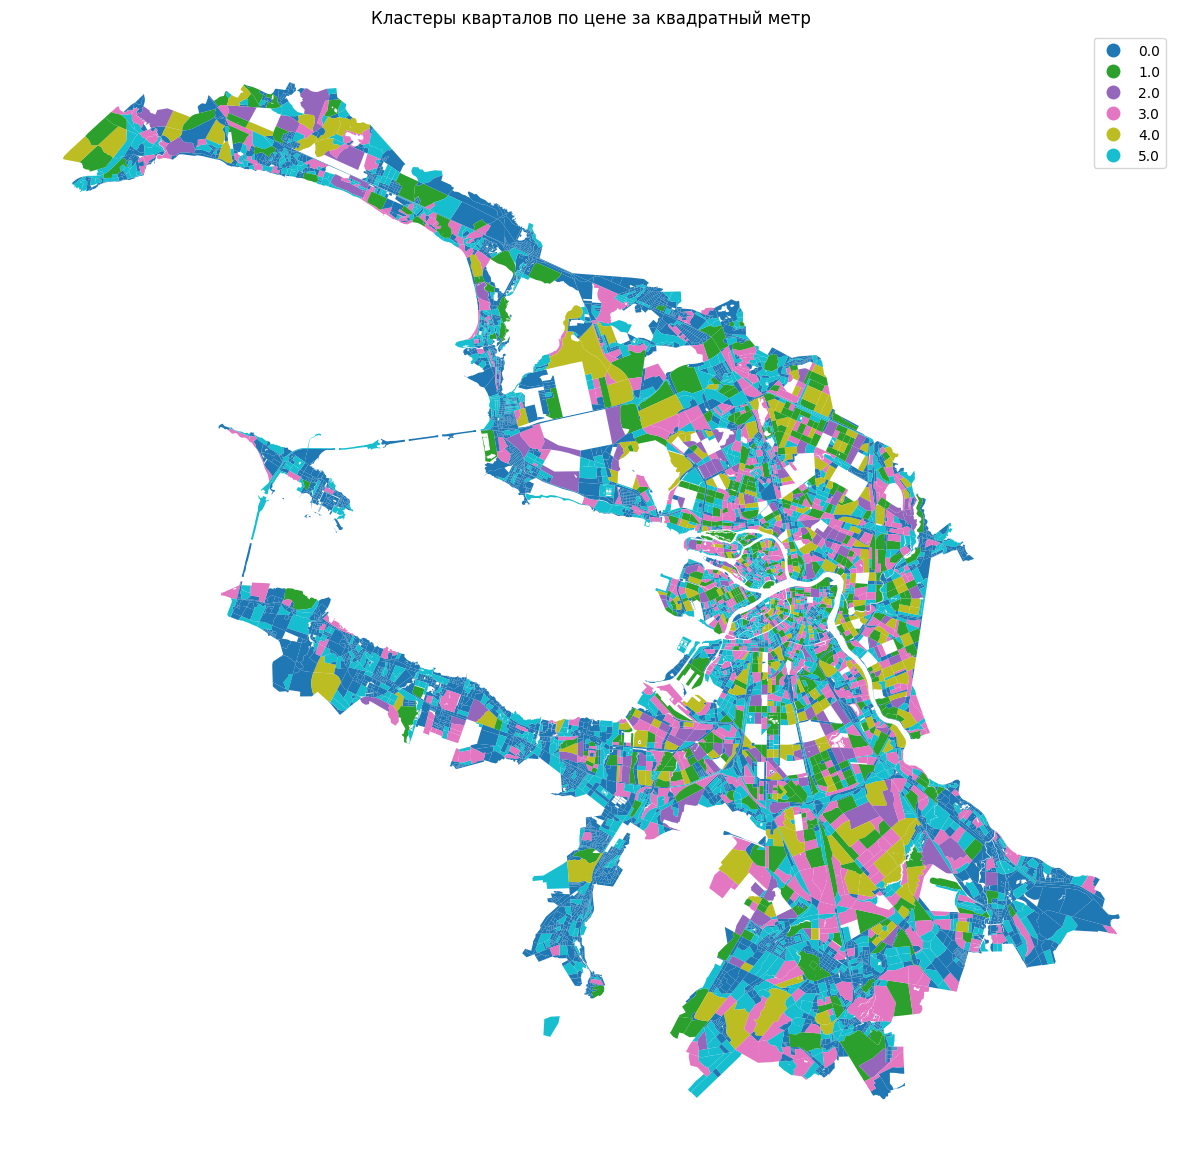

In [7]:
from sklearn.cluster import KMeans

# Берём только ненулевые и не NaN
X = blocks_clean[['total_cost_value']].dropna()

kmeans = KMeans(n_clusters=6, random_state=0)
blocks_clean.loc[X.index, 'cluster'] = kmeans.fit_predict(X)

# Визуализируем
blocks_clean.plot(
    column='cluster',
    categorical=True,
    legend=True,
    figsize=(15,15)
).set_axis_off()
plt.title('Кластеры кварталов по цене за квадратный метр')
plt.show()

In [8]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks_clean.select_dtypes(include=['number'])
num = num[num['log_price'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats

,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
residential,8561,0.00,1.00,0.51,0.68,0.43
business,8561,0.00,1.00,0.03,0.00,0.15
recreation,8561,0.00,1.00,0.19,0.00,0.33
industrial,8561,0.00,1.00,0.05,0.00,0.19
transport,8561,0.00,1.00,0.18,0.07,0.28
special,8561,0.00,1.00,0.01,0.00,0.10
agriculture,8561,0.00,1.00,0.01,0.00,0.11
share,8551,0.00,1.00,0.85,0.91,0.16
footprint_area,8561,0.00,"360,908.53","11,405.68","3,205.75","22,106.74"


In [9]:
blocks_clean.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'total_cost_value', 'site_area', 'price_per_sqm',
       'log_total_price', 'log_price', 'fsi', 'gsi', 'mxi', 'l', 'osr',
       'share_living', 'share_non_living', 'morphotype', 'area_accessibility',
       'log_total_cost_value', 'cluster'],
      dtype='object')

In [10]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "total_cost_value"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "log_price",
    "total_cost_value",
    "log_total_price",
    "price_per_sqm",
    'osr',
    'share_non_living',
    'share_living',
    'land_value_per_100m2',
    'log_total_cost_value',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype"]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    hpo_iter=24,
    n_clusters=10,
    inner_splits=5,
    outer_splits=5,
    iterations=1500,
    od_wait=300,
    seed=42,
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)
 

OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/24 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

...

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 363470150.2391485	total: 4.49ms	remaining: 10s
200:	learn: 112610439.9038277	total: 1.04s	remaining: 10.6s
400:	learn: 83884541.7599708	total: 2.05s	remaining: 9.39s
600:	learn: 73726325.1775038	total: 3.1s	remaining: 8.43s
800:	learn: 69331601.1953632	total: 4.11s	remaining: 7.37s
1000:	learn: 66161748.5103304	total: 5.15s	remaining: 6.37s
1200:	learn: 63461380.1086977	total: 6.16s	remaining: 5.32s
1400:	learn: 61324976.1535885	total: 7.22s	remaining: 4.31s
1600:	learn: 59831780.8498976	total: 8.24s	remaining: 3.28s
1800:	learn: 58431010.5960811	total: 9.29s	remaining: 2.25s
2000:	learn: 57213641.2241097	total: 10.3s	remaining: 1.22s
2200:	learn: 55950795.1425478	total: 11.4s	remaining: 191ms
2237:	learn: 55777486.8311922	total: 11.6s	remaining: 0us
use_services = False
{'r2': 0.9504081339541128, 'r2_std': 0.012445548021681942, 'mae': 82234071.2470522, 'mae_std': 23083930.003322653, 'rmse': 146458372.60405397, 'rmse_std': 33208849.235966414, 'nrmse': 0.031524738511811604, 'n

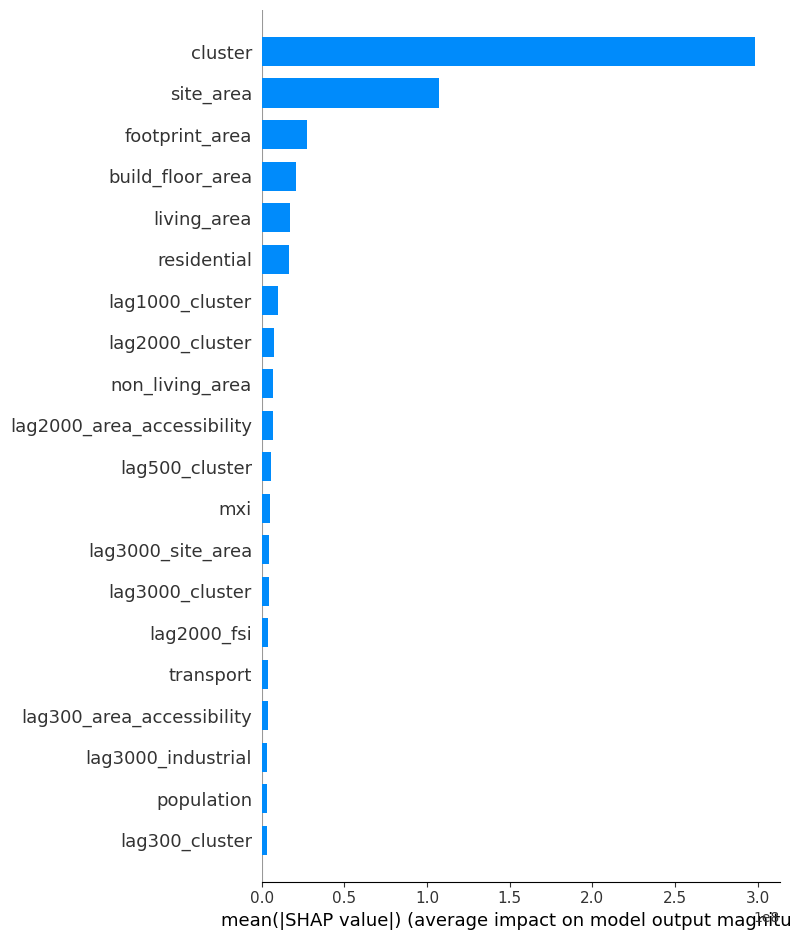

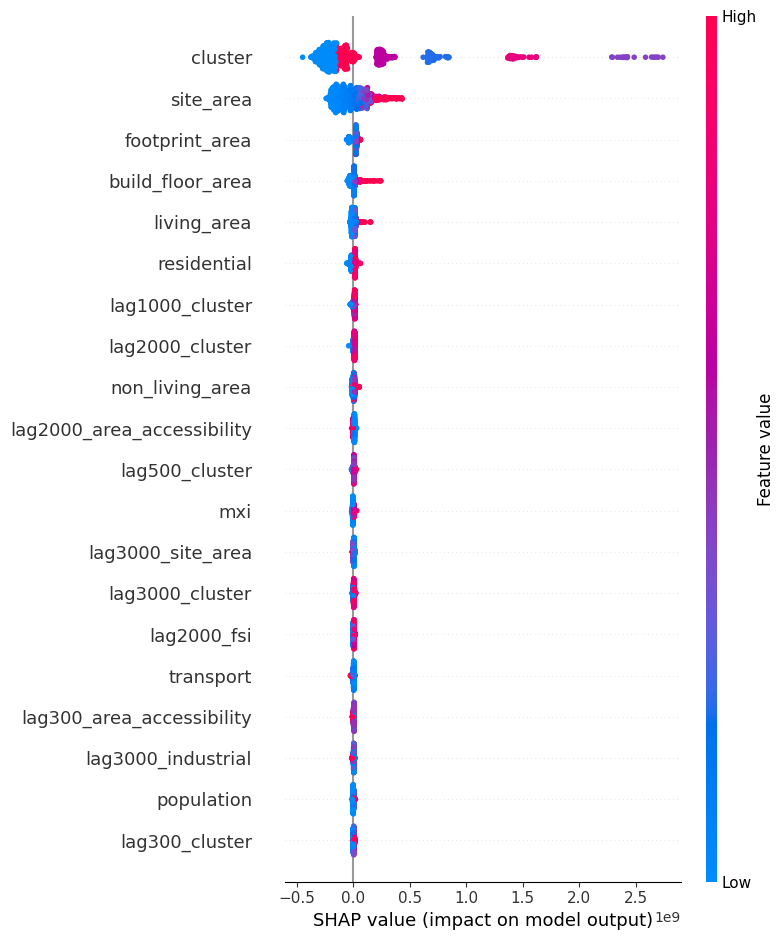

In [15]:
from catboost import Pool
from urbanomy.methods.land_value_modeling.training_utils import spatial_groups, build_radii_weights, add_lags_full_df, feature_names
from sklearn.model_selection import GroupKFold
import shap

# 1) same outer split as in training (pick first fold)
groups = spatial_groups(blocks_clean, cfg.n_clusters, random_state=cfg.seed)
_, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(blocks_clean, blocks_clean[target_col], groups))[0]
df_test = blocks_clean.iloc[test_idx].copy()

# 2) compute lags on FULL dataset once (so test "sees" neighbors from all blocks),
# then slice out test rows
cat_features = list(cfg.cat_features)
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col]

blocks_all = blocks_clean.copy()
for c in cat_features:
    blocks_all[c] = blocks_all[c].astype("string").fillna("missing")

weights = build_radii_weights(blocks_all, cfg.radius_list)
blocks_lag = add_lags_full_df(blocks_all, weights=weights, numeric_cols=numeric_feats)

# 3) final feature list = base feature_cols + computed lag / n_neighbors cols
base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + cat_features))
feats = feature_names(blocks_lag, base_cols_for_model, target_col)

df_test_lag = blocks_lag.loc[df_test.index]

# 4) sample for SHAP
sample_df = df_test_lag[feats].sample(n=min(1500, len(df_test_lag)), random_state=42)
sample_pool = Pool(sample_df, cat_features=cat_features, feature_names=feats)

# 5) SHAP
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(sample_pool, check_additivity=False)

shap.summary_plot(shap_vals, sample_df, plot_type="bar")
shap.summary_plot(shap_vals, sample_df)


In [23]:
# ============================================
# OOF Conformal Quantile Intervals (GroupKFold)
# ВЕРСИЯ ДЛЯ blocks_clean
# ============================================
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold

alpha = 0.10      # PI90; для PI95 поставьте 0.05
calib_folds = 5

# 0) Работаем строго с blocks_clean
data_df = blocks_clean.copy()

# Группы и outer split на blocks_clean
groups_all = spatial_groups(data_df, cfg.n_clusters, random_state=cfg.seed)
_, test_idx = list(
    GroupKFold(n_splits=cfg.outer_splits).split(data_df, data_df[cfg.target_col], groups_all)
)[0]
train_idx = np.setdiff1d(np.arange(len(data_df)), test_idx)

cat_features = [c for c in cfg.cat_features if c in data_df.columns]
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != cfg.target_col and c in data_df.columns]

# Категориальные в string
for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

# Лаги на blocks_clean
weights = build_radii_weights(data_df, cfg.radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

# Фичи только из data_lag (без отсутствующих)
base_cols_for_model = list(dict.fromkeys([c for c in cfg.feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, cfg.target_col)

df_train = data_lag.iloc[train_idx].copy()
df_test = data_lag.iloc[test_idx].copy()
groups_train = groups_all[train_idx]

def to_orig(x):
    x = np.asarray(x)
    return np.expm1(x) if cfg.target_col.startswith("log_") else x

# Параметры квантильных моделей
base_params = model.get_all_params() if "model" in locals() else {}
q_params = dict(
    depth=int(base_params.get("depth", 6)),
    learning_rate=float(base_params.get("learning_rate", 0.03)),
    l2_leaf_reg=float(base_params.get("l2_leaf_reg", 6.0)),
    random_strength=float(base_params.get("random_strength", 1.0)),
    bagging_temperature=float(base_params.get("bagging_temperature", 1.0)),
    bootstrap_type="Bayesian",
    grow_policy="SymmetricTree",
    random_seed=cfg.seed,
    iterations=max(cfg.iterations * 2, 3000),
    od_type="Iter",
    od_wait=cfg.od_wait,
    verbose=0,
)

a_lo = alpha / 2.0
a_hi = 1.0 - alpha / 2.0

# 1) OOF calibration scores на train
gkf_cal = GroupKFold(n_splits=calib_folds)
scores = []

for tr_rel, va_rel in gkf_cal.split(df_train, df_train[cfg.target_col], groups_train):
    tr_df = df_train.iloc[tr_rel]
    va_df = df_train.iloc[va_rel]

    tr_pool = Pool(tr_df[feats], label=tr_df[cfg.target_col], cat_features=cat_features, feature_names=feats)
    va_pool = Pool(va_df[feats], label=va_df[cfg.target_col], cat_features=cat_features, feature_names=feats)

    q_lo = CatBoostRegressor(loss_function=f"Quantile:alpha={a_lo}", eval_metric=f"Quantile:alpha={a_lo}", **q_params)
    q_hi = CatBoostRegressor(loss_function=f"Quantile:alpha={a_hi}", eval_metric=f"Quantile:alpha={a_hi}", **q_params)

    q_lo.fit(tr_pool, eval_set=va_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)
    q_hi.fit(tr_pool, eval_set=va_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)

    y_va = to_orig(va_df[cfg.target_col].to_numpy())
    lo_va = to_orig(q_lo.predict(va_df[feats]))
    hi_va = to_orig(q_hi.predict(va_df[feats]))
    lo_va, hi_va = np.minimum(lo_va, hi_va), np.maximum(lo_va, hi_va)

    s = np.maximum(lo_va - y_va, y_va - hi_va)
    scores.append(np.maximum(s, 0.0))

scores = np.concatenate(scores)
n = len(scores)
qhat = np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")

# 2) Финальные модели на всем train
train_pool = Pool(df_train[feats], label=df_train[cfg.target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[cfg.target_col], cat_features=cat_features, feature_names=feats)

q_lo_full = CatBoostRegressor(loss_function=f"Quantile:alpha={a_lo}", eval_metric=f"Quantile:alpha={a_lo}", **q_params)
q_hi_full = CatBoostRegressor(loss_function=f"Quantile:alpha={a_hi}", eval_metric=f"Quantile:alpha={a_hi}", **q_params)
point_model = CatBoostRegressor(loss_function="MAE", eval_metric="MAE", **q_params)

q_lo_full.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)
q_hi_full.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)
point_model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)

# 3) Интервалы и метрики на test
y_test = to_orig(df_test[cfg.target_col].to_numpy())
y_pred = to_orig(point_model.predict(df_test[feats]))

lo_test = to_orig(q_lo_full.predict(df_test[feats]))
hi_test = to_orig(q_hi_full.predict(df_test[feats]))
lo_test, hi_test = np.minimum(lo_test, hi_test), np.maximum(lo_test, hi_test)

pi_lo = lo_test - qhat
pi_hi = hi_test + qhat

coverage = np.mean((y_test >= pi_lo) & (y_test <= pi_hi))
avg_width = np.mean(pi_hi - pi_lo)

print(f"OOF Conformal PI{int((1-alpha)*100)} coverage: {coverage:.3f}")
print(f"Average PI width: {avg_width:,.2f}")
print(f"qhat: {qhat:,.2f}")

pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "pi_lo": pi_lo,
    "pi_hi": pi_hi,
    "in_interval": (y_test >= pi_lo) & (y_test <= pi_hi),
})
pred_df.head(10)


OOF Conformal PI90 coverage: 0.857
Average PI width: 470,572,348.63
qhat: 9,794,860.12


,y_true,y_pred,pi_lo,pi_hi,in_interval
0,"56,148,855.34","56,540,246.44","3,131,103.67","158,284,519.26",True
1,"10,013,499.18","14,462,688.63","6,618,799.04","107,755,181.01",True
2,"35,991,090.30","145,126,361.39","24,668,728.71","312,091,492.60",True
3,"137,597,528.95","69,312,134.49","-3,061,145.55","223,567,091.77",True
4,"264,870,951.23","508,723,599.61","282,090,618.51","709,825,688.88",False
5,"630,251,048.71","566,512,075.51","301,069,712.42","722,832,467.87",True
6,"780,430,208.72","933,581,563.51","647,746,745.99","1,247,142,159.62",True
7,"240,354,180.90","157,066,496.52","45,418,223.25","298,953,494.01",True
8,"555,125,478.17","480,496,691.22","325,932,119.19","701,271,313.83",True
9,"104,700,052.45","91,955,467.98","13,545,504.01","233,690,464.94",True


In [24]:
# === Trust Report for WAPE: holdout + CI + baselines + segment stability ===
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold

# ---------- helpers ----------
def to_original_scale(x, target_col: str):
    x = np.asarray(x)
    return np.expm1(x) if target_col.startswith("log_") else x

def wape(y_true, y_pred, eps: float = 1e-12):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    denom = np.sum(np.abs(y_true[mask]))
    if denom <= eps:
        return np.nan
    return np.sum(np.abs(y_true[mask] - y_pred[mask])) / denom

def bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = []
    idx_all = np.arange(n)
    for _ in range(n_boot):
        idx = rng.choice(idx_all, size=n, replace=True)
        vals.append(wape(y_true[idx], y_pred[idx]))
    vals = np.asarray(vals)
    return np.nanpercentile(vals, 100 * alpha / 2), np.nanpercentile(vals, 100 * (1 - alpha / 2))

# ---------- data ----------
data_df = blocks_clean.copy()  # важно: используем blocks_clean
target_col = cfg.target_col
cat_features = [c for c in cfg.cat_features if c in data_df.columns]
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

weights = build_radii_weights(data_df, cfg.radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)
base_cols_for_model = list(dict.fromkeys([c for c in cfg.feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# ---------- holdout split (grouped) ----------
groups = spatial_groups(data_lag, cfg.n_clusters, random_state=cfg.seed)
train_idx, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(data_lag, data_lag[target_col], groups))[0]

df_train = data_lag.iloc[train_idx].copy()
df_test = data_lag.iloc[test_idx].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# ---------- point model (MAE) ----------
model_eval = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=max(cfg.iterations * 2, 3000),
    od_type="Iter",
    od_wait=cfg.od_wait,
    bootstrap_type="Bayesian",
    grow_policy="SymmetricTree",
    random_seed=cfg.seed,
    verbose=0,
)
model_eval.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)

y_true = to_original_scale(df_test[target_col].to_numpy(), target_col)
y_pred = to_original_scale(model_eval.predict(df_test[feats]), target_col)

# ---------- main WAPE + CI ----------
wape_holdout = wape(y_true, y_pred)
wape_ci_low, wape_ci_high = bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=cfg.seed)

# ---------- baselines ----------
# 1) global median baseline
train_target_orig = to_original_scale(df_train[target_col].to_numpy(), target_col)
pred_med = np.full_like(y_true, np.median(train_target_orig), dtype=float)
wape_med = wape(y_true, pred_med)

# 2) median by land_use baseline (если есть)
if "land_use" in df_train.columns and "land_use" in df_test.columns:
    med_by_land_use = (
        pd.DataFrame({"land_use": df_train["land_use"].astype("string"), "y": train_target_orig})
        .groupby("land_use")["y"].median()
    )
    global_med = float(np.median(train_target_orig))
    pred_lu = df_test["land_use"].astype("string").map(med_by_land_use).fillna(global_med).to_numpy(float)
    wape_lu = wape(y_true, pred_lu)
else:
    wape_lu = np.nan

# ---------- segment stability ----------
eval_df = df_test.copy()
eval_df["y_true"] = y_true
eval_df["y_pred"] = y_pred
eval_df["abs_err"] = np.abs(eval_df["y_true"] - eval_df["y_pred"])

# by land_use
if "land_use" in eval_df.columns:
    seg_land_use = (
        eval_df.groupby("land_use", dropna=False)
        .apply(lambda g: pd.Series({
            "n": len(g),
            "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
        }))
        .sort_values("wape")
    )
else:
    seg_land_use = pd.DataFrame()

# by y_true decile
eval_df["price_decile"] = pd.qcut(eval_df["y_true"], q=10, labels=False, duplicates="drop")
seg_decile = (
    eval_df.groupby("price_decile", dropna=False)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
    }))
    .sort_index()
)

# ---------- report ----------
print("=== WAPE Trust Report ===")
if "metrics" in locals() and isinstance(metrics, dict) and "wape" in metrics:
    print(f"OOF CV WAPE: {metrics['wape']:.4f}  (std: {metrics.get('wape_std', np.nan):.4f})")
print(f"Holdout WAPE: {wape_holdout:.4f}")
print(f"Holdout WAPE 95% CI (bootstrap): [{wape_ci_low:.4f}, {wape_ci_high:.4f}]")
print(f"Baseline WAPE (global median): {wape_med:.4f}")
if np.isfinite(wape_lu):
    print(f"Baseline WAPE (median by land_use): {wape_lu:.4f}")

print("\nTop segments by land_use (lower WAPE is better):")
display(seg_land_use.head(15))

print("\nWAPE by price decile:")
display(seg_decile)


=== WAPE Trust Report ===
OOF CV WAPE: 0.1973  (std: 0.0256)
Holdout WAPE: 0.2073
Holdout WAPE 95% CI (bootstrap): [0.1991, 0.2164]
Baseline WAPE (global median): 0.8340
Baseline WAPE (median by land_use): 0.8275

Top segments by land_use (lower WAPE is better):


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_15528/431782809.py:107: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_15528/431782809.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,n,wape
land_use,,
SPECIAL,12.00,0.15
INDUSTRIAL,63.00,0.17
BUSINESS,127.00,0.19
RESIDENTIAL,"1,119.00",0.20
TRANSPORT,164.00,0.24
RECREATION,435.00,0.24
AGRICULTURE,5.00,0.52
None,1.00,169.74



WAPE by price decile:


,n,wape
price_decile,,
0,193.00,3.37
1,193.00,0.73
2,192.00,0.37
3,193.00,0.25
4,192.00,0.33
5,193.00,0.20
6,192.00,0.20
7,193.00,0.20
8,192.00,0.15


In [12]:
import json

artifacts = {
    "feature_cols": list(cfg.feature_cols),
    "cat_features": list(cfg.cat_features),
    "radius_list": list(cfg.radius_list),
    "target_col": cfg.target_col,
    "n_clusters": cfg.n_clusters,
    "seed": cfg.seed,
}

with open("artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

In [13]:
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

In [14]:


model_path = "land_value_catboost_20_02_2026.cbm"
model.save_model(model_path)

print(f"Model saved to {model_path}")

Model saved to land_value_catboost_20_02_2026.cbm
